In [ ]:
# ==========================================================
# IRIS FLOWER CLASSIFICATION PROJECT
# Complete Machine Learning Workflow
# ==========================================================

# -----------------------------
# Step 1 : Import Libraries
# -----------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from google.colab import files
uploaded = files.upload()


Saving Iris (1).csv to Iris (1) (2).csv


In [ ]:
# -------------------------------------------------------
# Step 2 : Load Dataset
# -------------------------------------------------------

df = pd.read_csv("Iris (1).csv")

print("="*60)
print("FIRST FIVE RECORDS")
print("="*60)

print(df.head())

FIRST FIVE RECORDS
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [ ]:
# -------------------------------------------------------
# Step 3 : Dataset Information
# -------------------------------------------------------

print("\n")
print("="*60)
print("DATASET INFORMATION")
print("="*60)

print(df.info())



DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None


In [ ]:
# -------------------------------------------------------
# Step 4 : Statistical Summary
# -------------------------------------------------------

print("\n")
print("="*60)
print("STATISTICAL SUMMARY")
print("="*60)

print(df.describe())



STATISTICAL SUMMARY
               Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count  150.000000     150.000000    150.000000     150.000000    150.000000
mean    75.500000       5.843333      3.054000       3.758667      1.198667
std     43.445368       0.828066      0.433594       1.764420      0.763161
min      1.000000       4.300000      2.000000       1.000000      0.100000
25%     38.250000       5.100000      2.800000       1.600000      0.300000
50%     75.500000       5.800000      3.000000       4.350000      1.300000
75%    112.750000       6.400000      3.300000       5.100000      1.800000
max    150.000000       7.900000      4.400000       6.900000      2.500000


In [ ]:
# -------------------------------------------------------
# Step 5 : Check Missing Values
# -------------------------------------------------------

print("\n")
print("="*60)
print("MISSING VALUES")
print("="*60)

print(df.isnull().sum())



MISSING VALUES
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [ ]:
# -------------------------------------------------------
# Step 6 : Check Duplicate Values
# -------------------------------------------------------

print("\n")
print("="*60)
print("DUPLICATES")
print("="*60)

print(df.duplicated().sum())



DUPLICATES
0


In [ ]:
# -------------------------------------------------------
# Step 7 : Drop ID Column
# -------------------------------------------------------

df = df.drop("Id", axis=1)

In [ ]:
# -------------------------------------------------------
# Step 8 : Display Target Classes
# -------------------------------------------------------

print("\n")
print("="*60)
print("TARGET CLASSES")
print("="*60)

print(df["Species"].value_counts())




TARGET CLASSES
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [ ]:
# -------------------------------------------------------
# Step 9 : Encode Target Variable
# -------------------------------------------------------

encoder = LabelEncoder()

df["Species"] = encoder.fit_transform(df["Species"])

print("\nEncoded Classes")

for i, name in enumerate(encoder.classes_):
    print(i, "=", name)


Encoded Classes
0 = Iris-setosa
1 = Iris-versicolor
2 = Iris-virginica


In [ ]:
# -------------------------------------------------------
# Step 10 : Separate Features and Target
# -------------------------------------------------------

X = df.drop("Species", axis=1)

y = df["Species"]

In [ ]:
# -------------------------------------------------------
# Step 11 : Train Test Split
# -------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Samples :", len(X_train))
print("Testing Samples :", len(X_test))


Training Samples : 120
Testing Samples : 30


In [ ]:
# -------------------------------------------------------
# Step 12 : Train Logistic Regression Model
# -------------------------------------------------------

model = LogisticRegression(max_iter=500)

model.fit(X_train, y_train)

LogisticRegression(max_iter=500)

In [ ]:
# -------------------------------------------------------
# Step 13 : Predict
# -------------------------------------------------------

y_pred = model.predict(X_test)

In [ ]:
# -------------------------------------------------------
# Step 14 : Accuracy
# -------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("\n")
print("="*60)
print("MODEL ACCURACY")
print("="*60)

print(f"Accuracy : {accuracy*100:.2f}%")



MODEL ACCURACY
Accuracy : 96.67%


In [ ]:
# -------------------------------------------------------
# Step 15 : Classification Report
# -------------------------------------------------------

print("\n")
print("="*60)
print("CLASSIFICATION REPORT")
print("="*60)

print(classification_report(
    y_test,
    y_pred,
    target_names=encoder.classes_
))



CLASSIFICATION REPORT
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



In [ ]:
# -------------------------------------------------------
# Step 16 : Confusion Matrix
# -------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

print("\n")
print("="*60)
print("CONFUSION MATRIX")
print("="*60)

print(cm)




CONFUSION MATRIX
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


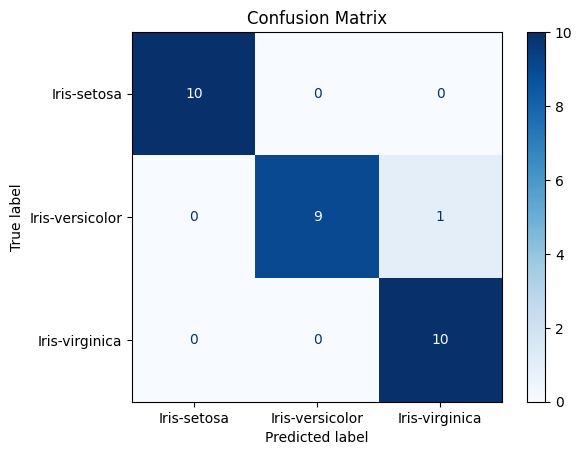

In [ ]:
# -------------------------------------------------------
# Step 17 : Plot Confusion Matrix
# -------------------------------------------------------

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [ ]:
# -------------------------------------------------------
# Step 18 : Feature Importance
# -------------------------------------------------------

importance = np.mean(np.abs(model.coef_), axis=0)

feature_names = X.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("\n")
print("="*60)
print("FEATURE IMPORTANCE")
print("="*60)

print(importance_df)



FEATURE IMPORTANCE
         Feature  Importance
2  PetalLengthCm    1.679402
3   PetalWidthCm    1.237981
1   SepalWidthCm    0.545813
0  SepalLengthCm    0.353345


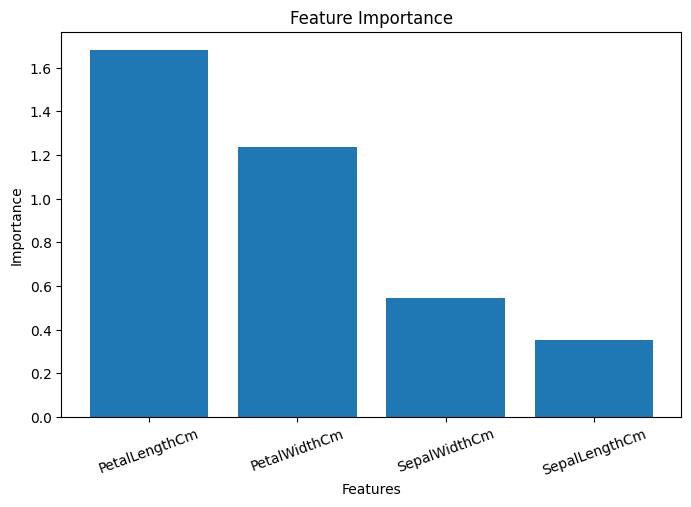

In [ ]:
# -------------------------------------------------------
# Step 19 : Plot Feature Importance
# -------------------------------------------------------

plt.figure(figsize=(8,5))

plt.bar(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.title("Feature Importance")

plt.xlabel("Features")

plt.ylabel("Importance")

plt.xticks(rotation=20)

plt.show()

In [ ]:
# -------------------------------------------------------
# Step 20 : Predict New Flower
# -------------------------------------------------------

print("\n")
print("="*60)
print("NEW FLOWER PREDICTION")
print("="*60)

new_flower = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(new_flower)

flower = encoder.inverse_transform(prediction)

print("Predicted Flower Species :", flower[0])



NEW FLOWER PREDICTION
Predicted Flower Species : Iris-setosa


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [ ]:
# -------------------------------------------------------
# Step 21 : Predict Multiple Flowers
# -------------------------------------------------------

flowers = [

    [5.1,3.5,1.4,0.2],

    [6.5,3.0,5.2,2.0],

    [5.9,2.9,4.2,1.5]

]

predictions = model.predict(flowers)

species = encoder.inverse_transform(predictions)

print("\nMultiple Predictions")

for i in range(len(flowers)):
    print(f"Flower {i+1} --> {species[i]}")



Multiple Predictions
Flower 1 --> Iris-setosa
Flower 2 --> Iris-virginica
Flower 3 --> Iris-versicolor


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [ ]:
# -------------------------------------------------------
# Step 22 : Save Model
# -------------------------------------------------------

import joblib

joblib.dump(model, "iris_model.pkl")

joblib.dump(encoder, "label_encoder.pkl")

print("\nModel Saved Successfully.")


Model Saved Successfully.


In [ ]:
# -------------------------------------------------------
# Step 23 : Load Saved Model
# -------------------------------------------------------

loaded_model = joblib.load("iris_model.pkl")

loaded_encoder = joblib.load("label_encoder.pkl")

sample = [[6.2,2.8,4.8,1.8]]

pred = loaded_model.predict(sample)

species = loaded_encoder.inverse_transform(pred)

print("\nPrediction Using Saved Model")

print(species[0])

# -------------------------------------------------------
# END OF PROJECT
# -------------------------------------------------------


Prediction Using Saved Model
Iris-virginica


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
